In [229]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [230]:
df=pd.read_csv("ford.csv")

In [231]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [232]:
df.shape

(17966, 9)

In [233]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  str    
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  str    
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  str    
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 1.2 MB


In [234]:
numeric_colomuns={'year' , 'price' ,'mileage', 'tax' , 'mpg' ,'engineSize'  }

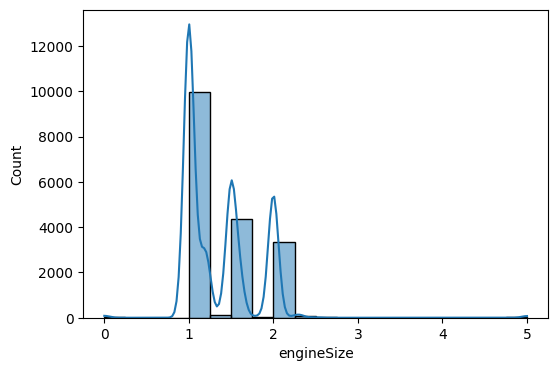

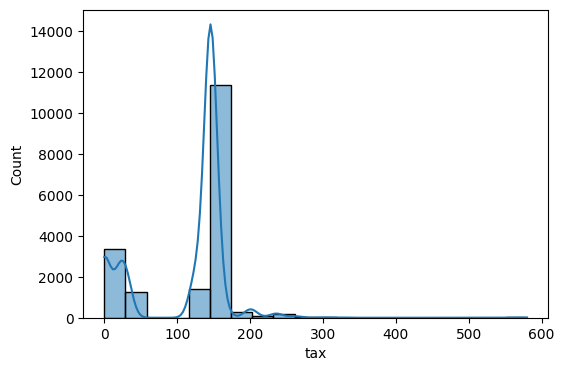

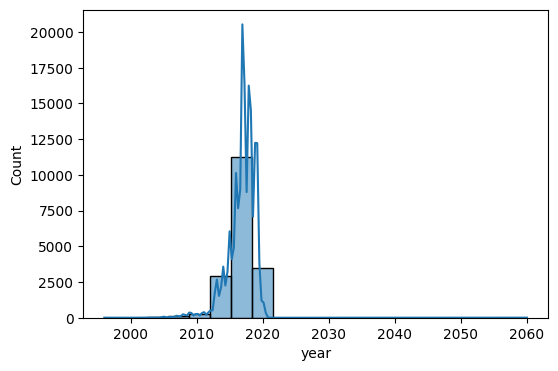

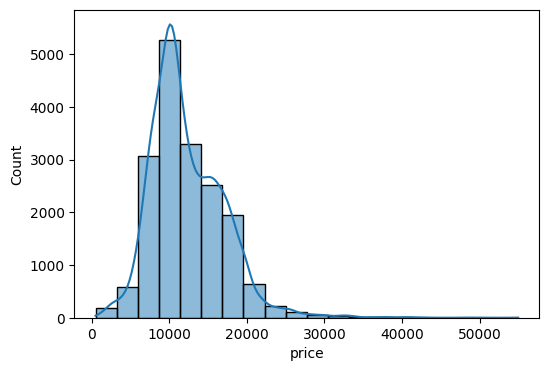

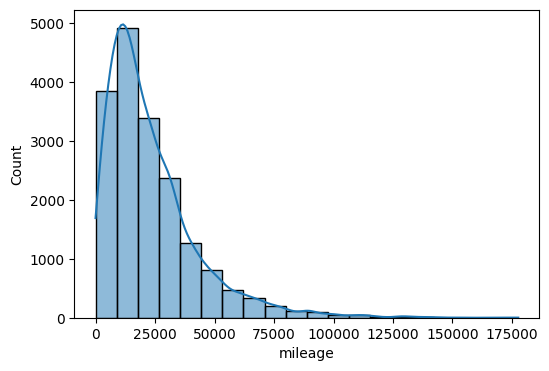

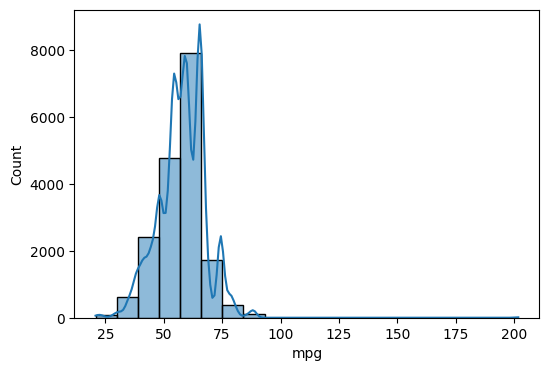

In [235]:
for col in numeric_colomuns :
        plt.figure(figsize=(6, 4))
        sns.histplot(df[col], kde=True, bins=20)  


<Axes: xlabel='count', ylabel='model'>

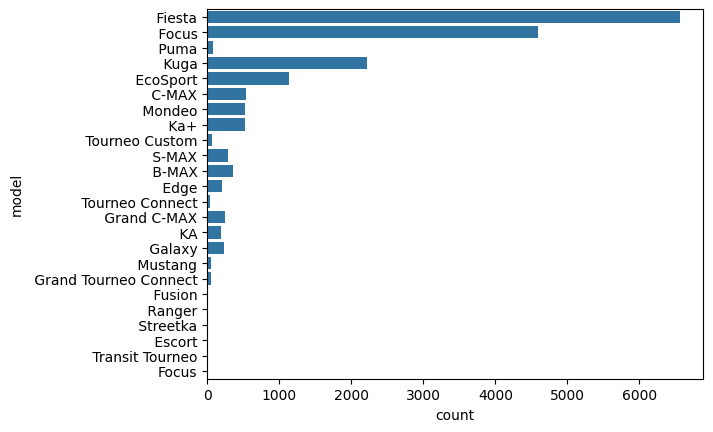

In [236]:

sns.countplot(y=df['model'])

<Axes: xlabel='transmission', ylabel='count'>

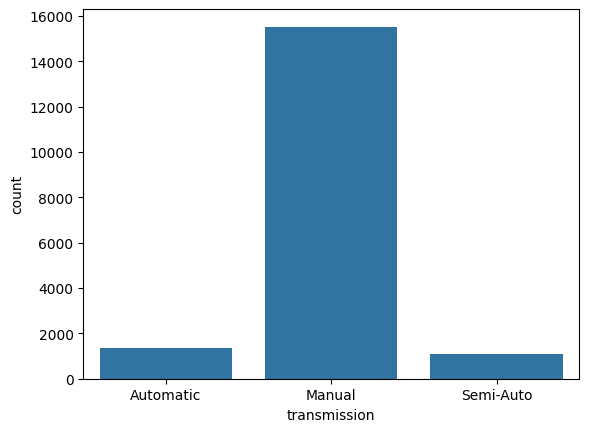

In [237]:
sns.countplot(x=df['transmission'] )

<Axes: xlabel='fuelType', ylabel='count'>

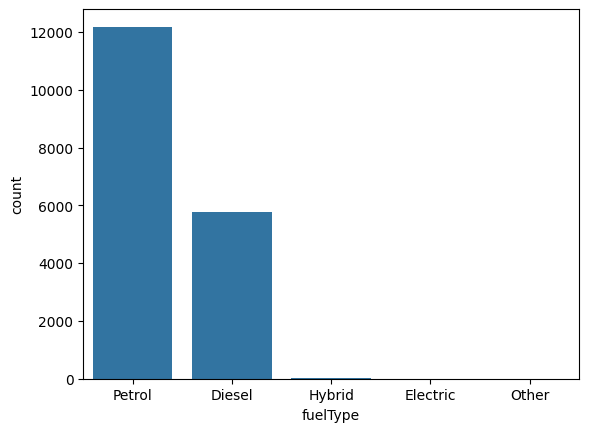

In [238]:
sns.countplot(x=df['fuelType'])

KeyboardInterrupt: 

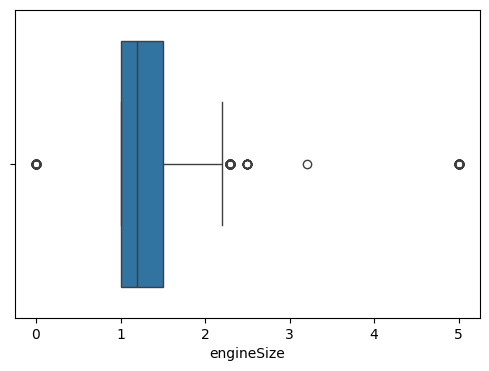

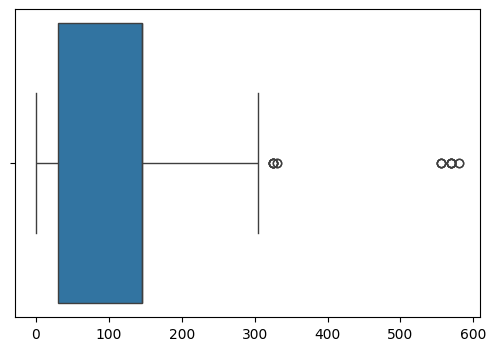

In [239]:
for col in numeric_colomuns :
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=df[col]);

In [ ]:
df = df[df['mileage'] <= 100000]

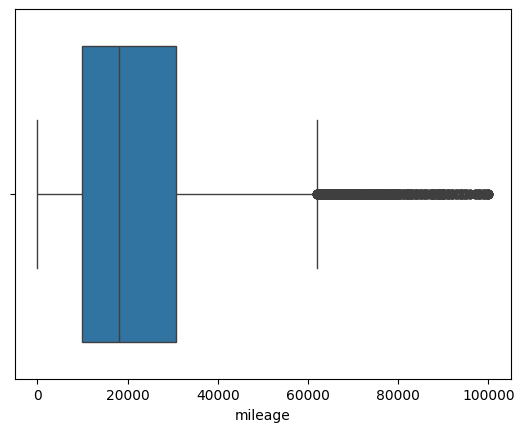

In [ ]:
sns.boxplot(x=df['mileage']);


In [ ]:
df = df[df['price'] < df['price'].quantile(0.95)]

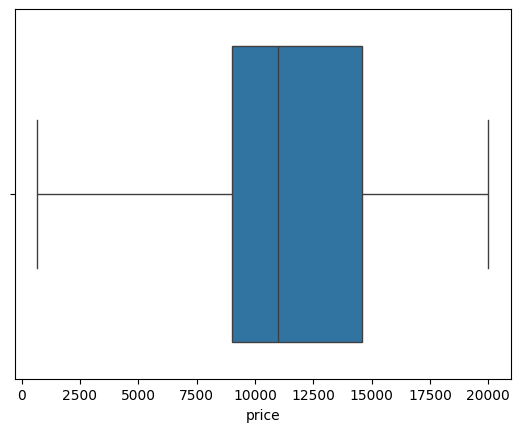

In [ ]:
sns.boxplot(x=df['price']);

<Axes: >

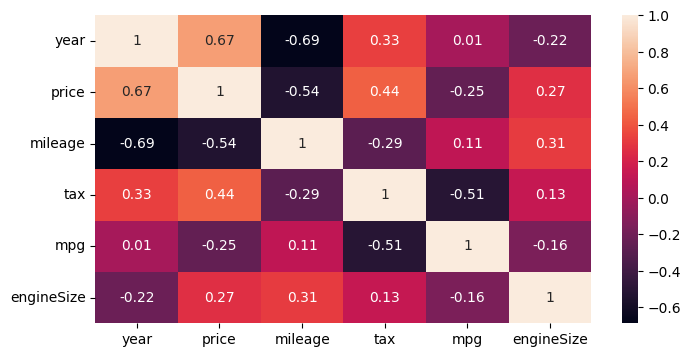

In [ ]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(numeric_only=True), annot=True)

 # Data cleaning and preprocessing 

In [ ]:
df_cleaned =df.copy()

In [ ]:
df_cleaned = df.drop_duplicates()

In [ ]:
df_cleaned.shape

(16804, 9)

In [ ]:
df_cleaned.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [ ]:


df_cleaned = pd.get_dummies(df_cleaned, columns=['model', 'transmission', 'fuelType'], drop_first=True)

In [ ]:
df_cleaned.head()

,year,price,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,charges_bin
0,0,12000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,2
1,0,14000,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,2
2,0,13000,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,2
3,1,17500,0,0,-1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,3
4,1,16500,-1,0,-1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,3


In [ ]:
df_cleaned.head()

,year,price,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,charges_bin
0,0,12000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,2
1,0,14000,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,2
2,0,13000,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,2
3,1,17500,0,0,-1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,3
4,1,16500,-1,0,-1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,3


In [ ]:
df_cleaned.head()

,year,price,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,charges_bin
0,0,12000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,2
1,0,14000,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,2
2,0,13000,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,2
3,1,17500,0,0,-1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,3
4,1,16500,-1,0,-1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,3


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cols=['year', 'mileage','tax','mpg', 'engineSize']
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [ ]:
df_cleaned

,year,price,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.096357,12000,-0.423559,0.629765,-0.096714,-0.835311,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,0.604099,14000,-0.808419,0.629765,-0.096714,-0.835311,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0.096357,13000,-0.619215,0.629765,-0.096714,-0.835311,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
3,1.111842,17500,-0.731178,0.548841,-1.979884,0.495018,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
4,1.111842,16500,-1.234790,0.548841,-1.070768,-0.835311,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.096357,8999,-0.381152,0.629765,-1.243933,0.228952,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
17962,-1.426869,7499,0.965103,-1.312428,-0.096714,-0.835311,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
17963,-0.919127,9999,-0.924702,-1.474278,0.942276,0.761083,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
17964,0.604099,8299,-1.037058,0.548841,-0.096714,-0.303179,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True


In [ ]:
from scipy.stats import pearsonr

selected_features = [
    'year', 'price', 'mileage', 'tax', 'mpg', 'engineSize',
    'model_ C-MAX', 'model_ EcoSport', 'model_ Edge', 'model_ Escort',
    'model_ Tourneo Connect', 'model_ Tourneo Custom', 'model_ Transit Tourneo',
    'model_Focus', 'transmission_Manual', 'transmission_Semi-Auto',
    'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol'
]

correlations = {}
for feature in selected_features:
    try:
        x = pd.to_numeric(df_cleaned[feature], errors='coerce')
        y = pd.to_numeric(df_cleaned['price'], errors='coerce')
        
        mask = x.notna() & y.notna()
        corr, _ = pearsonr(x[mask], y[mask])
        correlations[feature] = corr
    except Exception as e:
        print(f"Skipping {feature}: {e}")

correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])
correlation_df.sort_values(by='Pearson Correlation', ascending=False)

,Feature,Pearson Correlation
1,price,1.000000
0,year,0.664952
3,tax,0.434480
5,engineSize,0.267077
8,model_ Edge,0.125423
15,transmission_Semi-Auto,0.089757
11,model_ Tourneo Custom,0.076944
7,model_ EcoSport,0.051873
10,model_ Tourneo Connect,0.019129
17,fuelType_Hybrid,0.012880


In [ ]:
cat_features = [
    
'model_ C-MAX', 'model_ EcoSport', 'model_ Edge', 'model_ Escort',
'model_ Tourneo Connect', 'model_ Tourneo Custom', 'model_ Transit Tourneo',
'model_Focus', 'transmission_Manual', 'transmission_Semi-Auto',
'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol'

]

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['price'], q=4, labels=False)
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
fuelType_Petrol,586.893405,0.0,Reject Null (Keep Feature)
transmission_Manual,522.65891,0.0,Reject Null (Keep Feature)
model_ Edge,238.119462,0.0,Reject Null (Keep Feature)
model_ C-MAX,182.168884,0.0,Reject Null (Keep Feature)
transmission_Semi-Auto,126.69071,0.0,Reject Null (Keep Feature)
model_ Tourneo Custom,94.427655,0.0,Reject Null (Keep Feature)
model_ EcoSport,93.618211,0.0,Reject Null (Keep Feature)
model_ Tourneo Connect,10.243533,0.016606,Reject Null (Keep Feature)
fuelType_Hybrid,7.454086,0.05875,Accept Null (Drop Feature)
fuelType_Electric,6.000714,0.111575,Accept Null (Drop Feature)


In [ ]:
final_df=df_cleaned[['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize','fuelType_Petrol',
'transmission_Manual',
'model_ Edge',
'model_ C-MAX',
'transmission_Semi-Auto',
'model_ Tourneo Custom',
'model_ EcoSport',
'model_ Tourneo Connect' ]]

In [ ]:
final_df

,year,price,mileage,tax,mpg,engineSize,fuelType_Petrol,transmission_Manual,model_ Edge,model_ C-MAX,transmission_Semi-Auto,model_ Tourneo Custom,model_ EcoSport,model_ Tourneo Connect
0,0.096357,12000,-0.423559,0.629765,-0.096714,-0.835311,True,False,False,False,False,False,False,False
1,0.604099,14000,-0.808419,0.629765,-0.096714,-0.835311,True,True,False,False,False,False,False,False
2,0.096357,13000,-0.619215,0.629765,-0.096714,-0.835311,True,True,False,False,False,False,False,False
3,1.111842,17500,-0.731178,0.548841,-1.979884,0.495018,True,True,False,False,False,False,False,False
4,1.111842,16500,-1.234790,0.548841,-1.070768,-0.835311,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.096357,8999,-0.381152,0.629765,-1.243933,0.228952,True,True,False,False,False,False,False,False
17962,-1.426869,7499,0.965103,-1.312428,-0.096714,-0.835311,True,True,False,False,False,False,False,False
17963,-0.919127,9999,-0.924702,-1.474278,0.942276,0.761083,False,True,False,False,False,False,False,False
17964,0.604099,8299,-1.037058,0.548841,-0.096714,-0.303179,True,True,False,False,False,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x = final_df.drop('price', axis=1)
y=final_df['price']

In [ ]:
train_x, test_x, train_y, test_y = train_test_split( x, y, test_size=0.20, random_state=42)

In [ ]:
from  sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()
model.fit(train_x, train_y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
y_pred = model.predict(test_x)
y_pred 

array([12564.82809031, 13787.99351498,  7188.98208536, ...,
       10563.44473946, 10434.87799806, 12585.17411943], shape=(3361,))

In [ ]:
from sklearn.metrics import r2_score    
r2 = r2_score(test_y, y_pred)   
p = test_x.shape[1]
n = test_x.shape[0]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
adjusted_r2   

0.731832444705952